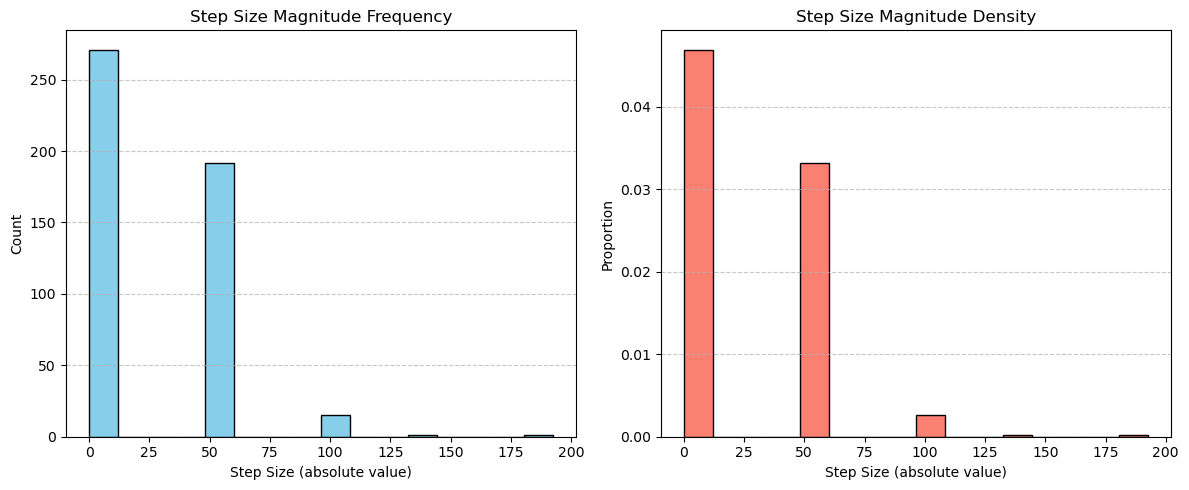

In [3]:
### optimized performance using pd.concat
##absolute values of step sizes
import pandas as pd
import matplotlib.pyplot as plt
import os

# File paths
input_excel = r'C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\CD2AP_BE\subunit_data_CD2AP_BE.xlsx'
output_steps_file = input_excel.replace('.xlsx', '_StepSizeSeries.xlsx')
output_all_steps_file = input_excel.replace('.xlsx', '_AllStepSizes.xlsx')
output_histogram_path = input_excel.replace('.xlsx', '_StepSizeHistogram.png')

# Read input
data = pd.read_excel(input_excel)
time_points = data.iloc[:, 0]
data_columns = data.iloc[:, 1:]

# Store per-column step size series
step_data_list = []
all_steps = []

for col in data_columns.columns:
    series = data[col].dropna().values
    steps = [round(abs(series[i] - series[i - 1]), 3) for i in range(1, len(series))]  # absolute and rounded
    all_steps.extend(steps)
    # Align with time points (shifted by 1 since step i = val[i] - val[i-1])
    col_step_series = pd.Series([None] + steps, name=col)
    step_data_list.append(col_step_series)

# Create DataFrame with step sizes
step_size_df = pd.concat(step_data_list, axis=1)
step_size_df.insert(0, data.columns[0], time_points)

# Save individual step sizes by identifier
step_size_df.to_excel(output_steps_file, index=False)

# Save all absolute step sizes in one column
all_steps_df = pd.DataFrame({"Step Size (|Δ|)": all_steps})
all_steps_df.to_excel(output_all_steps_file, index=False)

# Plot histogram
plt.figure(figsize=(12, 5))

# Frequency Histogram
plt.subplot(1, 2, 1)
plt.hist(all_steps, bins='auto', color='skyblue', edgecolor='black')
plt.title("Step Size Magnitude Frequency")
plt.xlabel("Step Size (absolute value)")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Normalized Histogram (Density)
plt.subplot(1, 2, 2)
plt.hist(all_steps, bins='auto', color='salmon', edgecolor='black', density=True)
plt.title("Step Size Magnitude Density")
plt.xlabel("Step Size (absolute value)")
plt.ylabel("Proportion")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(output_histogram_path, dpi=300)
plt.show()


